# 1. Data Import

As always, we begin by importing the necessary libraries, loading the dataset for analysis, and displaying the first few rows to better understand what's in the dataset.

We'll be importing the CSVs exported raw from the Samsung Health app:
- Dates of menstruation (`cycle_flow_march_09.csv`)
- Daily vitality scores (`vitality_score_march_09.csv`)
- Basal Body Temperature (BBT) changes (`cycle_daily_temperature_changes_march_09.csv`)


In [2]:
import pandas as pd

# Get Period Dates
PERIOD_PATH = "raw-data/cycle_flow_march_09.csv"

period_df = pd.read_csv(PERIOD_PATH, skiprows=1, index_col=False)

# Convert 'start_time' to datetime
period_df['start_time'] = pd.to_datetime(period_df['start_time'])

# Sort dates just in case
period_df = period_df.sort_values(by='start_time')

# Calculate the difference between consecutive dates
period_df['diff'] = period_df['start_time'].diff().dt.days

# The first day of a cycle is where the difference is not 1 day
first_days = period_df.loc[period_df['diff'] != 1, 'start_time'].reset_index(drop=True)

In [ ]:
# Import vitality scores
VITALITY_PATH = "raw-data/vitality_score_march_09.csv"

vitality_df = pd.read_csv(VITALITY_PATH, skiprows=1, index_col=False)

# Convert 'day_time' to datetime type
vitality_df['day_time'] = pd.to_datetime(vitality_df['day_time'])

# Check the columns of interest
vitality_df[
    [
        "day_time", # <- the "absolute" date of the vitality score (not timezone aware)
        "shr_value", # <- the average shown in the app
        "shrv_value", # <- the average shown in the app
        "sleep_duration" # in milliseconds
    ]
].tail()


,day_time,shr_value,shrv_value,sleep_duration
77,2025-03-05 00:00:00.000,64.870550,40.826360,26001428
78,2025-03-06 00:00:00.000,71.455950,34.428800,28320000
79,2025-03-07 00:00:00.000,66.410890,41.001750,27467142
80,2025-03-08 00:00:00.000,66.483765,44.317375,26682857
81,2025-03-09 00:00:00.000,68.430660,41.548447,25097142


In [ ]:
# Get BBT
BBT_PATH = "raw-data/cycle_daily_temperature_changes_march_09.csv"

bbt_df = pd.read_csv(BBT_PATH, skiprows=1, index_col=False)
bbt_df['day_time'] = pd.to_datetime(bbt_df['day_time'])

# Only get days with BBT data
filtered_bbt_df = bbt_df[(bbt_df["temperature"] > 0) & (bbt_df['day_time'] > pd.to_datetime("2024-08-09"))] 

filtered_bbt_df.info()

# 2. Data Exploration

Next, we will visualize the data to see if it makes sense. For our variables of interest—sleeping heart rate (HR) and heart rate variability (HRV) should reflect cyclical patterns: Lower HR and higher HRV in the follicular phase, higher HR and lower HRV in the luteal phase.

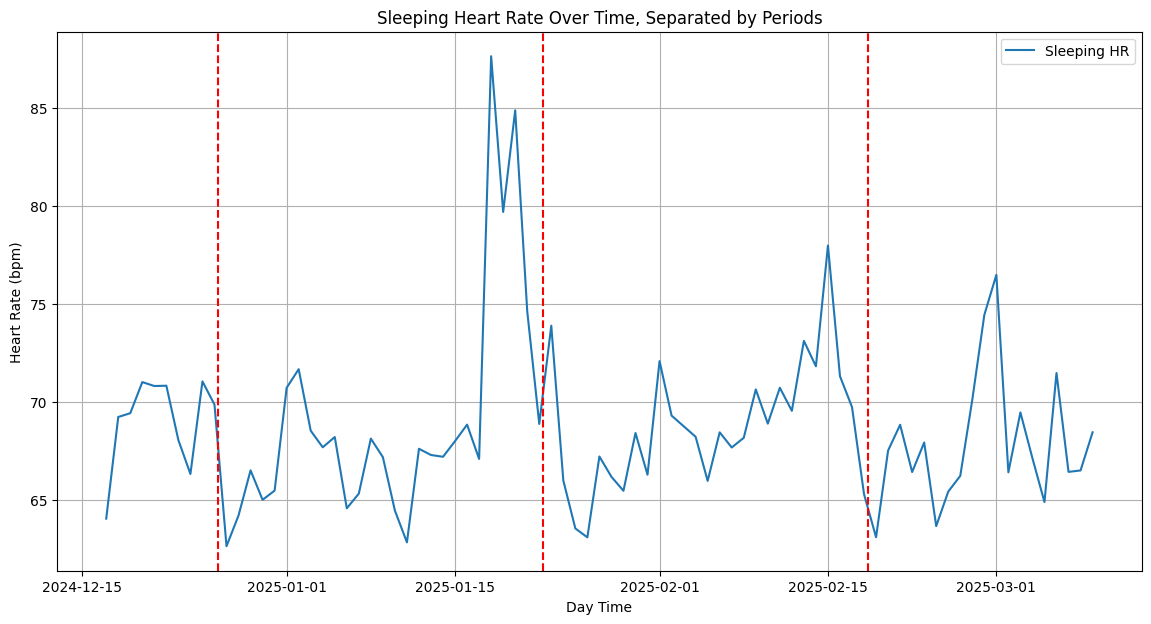

In [ ]:
import matplotlib.pyplot as plt

# Plot Sleeping HR
plt.figure(figsize=(14, 7))
plt.plot(vitality_df['day_time'], vitality_df['shr_value'], label='Sleeping HR')
plt.xlabel('Day Time')
plt.ylabel('Heart Rate (bpm)')
plt.title('Sleeping Heart Rate Over Time, Separated by Periods')

# Mark First Day of Period
for day in first_days:
    if vitality_df['day_time'].min() <= day <= vitality_df['day_time'].max():
        plt.axvline(x=day, color='r', linestyle='--', label='First Day of Period' if day == first_days.iloc[0] else "")

plt.legend()
plt.grid(True)

plt.show()

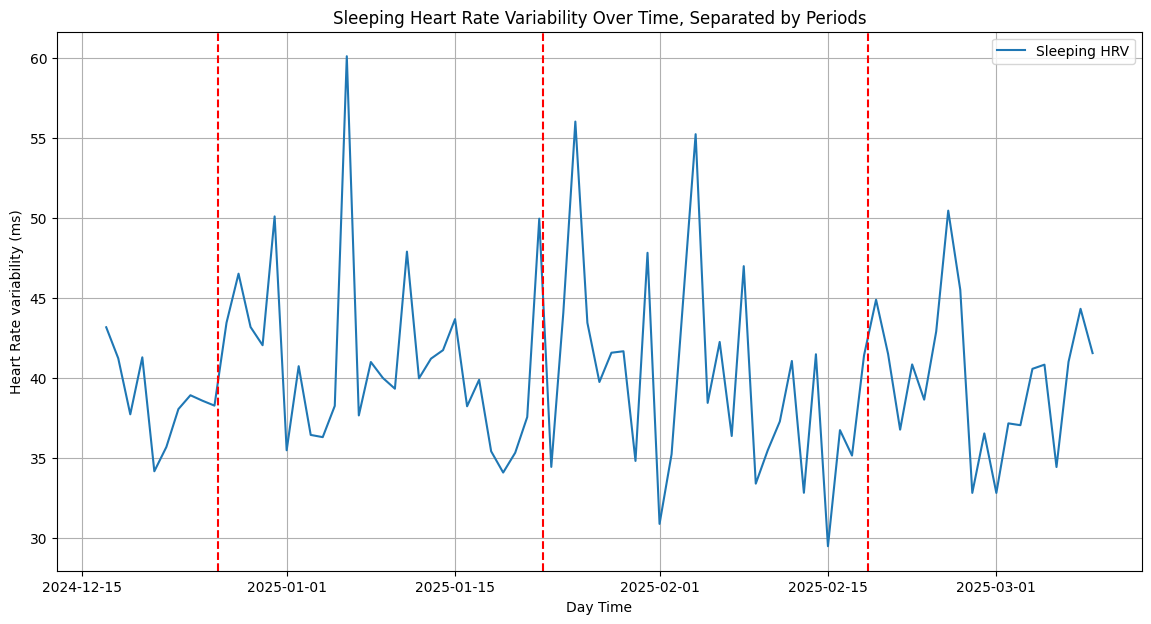

In [ ]:
# Sleeping HRV
# Plot the data
plt.figure(figsize=(14, 7))
plt.plot(vitality_df['day_time'], vitality_df['shrv_value'], label='Sleeping HRV')
plt.xlabel('Day Time')
plt.ylabel('Heart Rate variability (ms)')
plt.title('Sleeping Heart Rate Variability Over Time, Separated by Periods')

# Mark First Day of Period
for day in first_days:
    if vitality_df['day_time'].min() <= day <= vitality_df['day_time'].max():
        plt.axvline(x=day, color='r', linestyle='--', label='First Day of Period' if day == first_days.iloc[0] else "")
        
plt.legend()
plt.grid(True)

        
plt.show()

# 3. Feature Engineering (Menstrual Phase)

In order to determine the menstrual phases, I need to know the date of ovulation. However, ovulation dates are not included in the raw data, so I would need to reverse engineer them from BBT data.

Ovulation can be detected through several physiological measures; the two most accessible ones are cervical mucus color and texture and BBT readings (and I only have data for the latter). 

After ovulation, the released egg cell transforms into the corpus luteum, which starts producing progesterone. This hormonal change leads to a rise in basal body temperature that persists until the next menstruation.

In [ ]:
# Calculate Menstrual Phase
# Step 1: Find points where BBT increases by at least 0.2°C
filtered_bbt_df.loc[:, "rise_detected"] = filtered_bbt_df["temperature_delta"] >= 0.2

# Step 2: Compute rolling baseline temperature before the rise (4-day average before each day)
filtered_bbt_df.loc[:, "baseline_BBT"] = (
    filtered_bbt_df["temperature"].shift(1).rolling(window=4, min_periods=3).mean()
)

# Step 3: Check if BBT stays elevated after the rise for at least 3 consecutive days
filtered_bbt_df.loc[:, "sustained_luteal"] = (
    filtered_bbt_df["temperature"].rolling(window=3, min_periods=3).mean()
    >= filtered_bbt_df["baseline_BBT"] + 0.2
)

# Step 4: Detect ovulation (first day of sustained increase)
filtered_bbt_df.loc[:, "ovulation"] = filtered_bbt_df["sustained_luteal"] & ~filtered_bbt_df[
    "sustained_luteal"
].shift(1, fill_value=False)

# Step 5: We likely have multiple candidate ovulation dates, so we need to filter them
filtered_bbt_df.loc[:, "cycle_start"] = filtered_bbt_df["day_time"].apply(
    lambda x: first_days[first_days <= x].max()
)

# Step 6: Find the latest ovulation date within each cycle
latest_ovulation_per_cycle = (
    filtered_bbt_df[filtered_bbt_df["ovulation"] == True]
    .groupby("cycle_start")["day_time"]
    .max()
)

# Step 7: Keep only the latest ovulation per cycle and adjust by -2 days
filtered_bbt_df.loc[:, "ovulation"] = filtered_bbt_df["day_time"].isin(latest_ovulation_per_cycle - pd.Timedelta(days=2))


/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_97132/2157046608.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df["rise_detected"] = filtered_bbt_df["temperature_delta"] >= 0.2
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_97132/2157046608.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df["baseline_BBT"] = (
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_97132/2157046608.py:11: SettingWithCopyWarning: 
A value is trying to be set on a 

We'll visualize the approximated ovulation dates as a sanity check. As you might notice, our algorithm was not successful in detecting ovulation for one cycle (October 2024).

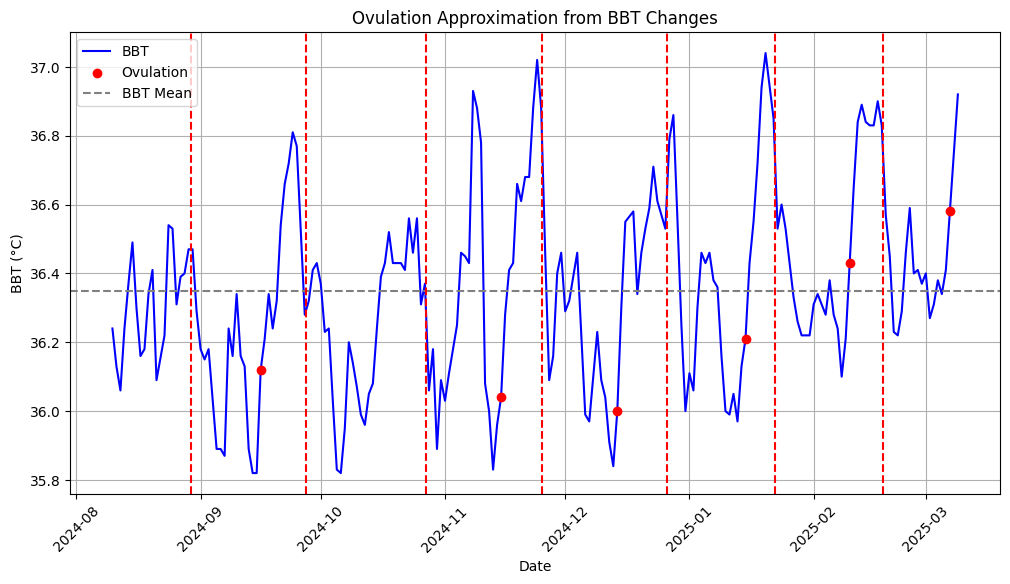

In [ ]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(
    filtered_bbt_df["day_time"],
    filtered_bbt_df["temperature"],
    label="BBT",
    color="blue",
)
plt.scatter(
    filtered_bbt_df["day_time"][filtered_bbt_df["ovulation"]],
    filtered_bbt_df["temperature"][filtered_bbt_df["ovulation"]],
    color="red",
    label="Ovulation",
    zorder=3,
)
plt.axhline(
    filtered_bbt_df["temperature"].mean(),
    linestyle="--",
    color="gray",
    label="BBT Mean",
)

plt.xlabel("Date")
plt.ylabel("BBT (°C)")
plt.title("Ovulation Approximation from BBT Changes")
plt.xticks(rotation=45)
plt.grid()

# Mark First Day of Period
for day in first_days:
    if filtered_bbt_df["day_time"].min() <= day <= filtered_bbt_df["day_time"].max():
        plt.axvline(
            x=day,
            color="r",
            linestyle="--",
            label="First Day of Period" if day == first_days.iloc[0] else "",
        )

plt.legend()

plt.show()

In [ ]:
# Step 1: Forward-fill the next ovulation date (to label pre/post phases)
filtered_bbt_df.loc[:, "last_ovulation"] = (
    filtered_bbt_df["day_time"].where(filtered_bbt_df["ovulation"]).ffill()
)

# Step 2: Assign phase labels
filtered_bbt_df.loc[:, "phase"] = "follicular"  # Default
filtered_bbt_df.loc[
    (filtered_bbt_df["cycle_start"] < filtered_bbt_df["last_ovulation"]) &
    (filtered_bbt_df["day_time"] >= filtered_bbt_df["last_ovulation"]), "phase"
] = "luteal"


/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_97132/1802914720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df["last_ovulation"] = (
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_97132/1802914720.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df.loc[:, "phase"] = "follicular"  # Default


The final step is to merge all of the columns of interest into one dataframe and account for any missing values. With this, our data cleaning and preprocessing is done and we can move on to analyses!

In [ ]:
# Merging relevant columns into a single DataFrame for easier analysis
analysis_df = pd.merge(
    vitality_df[["day_time", "shr_value", "shrv_value", "sleep_duration"]],
    filtered_bbt_df[["day_time", "temperature", "phase"]],
    how="left",
    left_on="day_time",
    right_on="day_time",
)

# Save the analysis DataFrame to a CSV file
analysis_df.to_csv("labeled_data.csv", index=False)

# Fill missing BBT values with the average of the previous and next values
# and then fill any remaining NaN values with the overall mean
analysis_df.loc[:, "temperature"] = analysis_df["temperature"].fillna(
    (analysis_df["temperature"].shift() + analysis_df["temperature"].shift(-1)) / 2
)
analysis_df.loc[:, "temperature"] = analysis_df["temperature"].fillna(
    analysis_df["temperature"].mean()
)

# Fill missing phase values with the next value 
# and then fill any remaining NaN values with the previous value
analysis_df.loc[:, "phase"] = analysis_df.fillna(method="ffill").fillna(method="bfill")

# 4. MANCOVA analysis
## 4.1. Transformation

MAN(C)OVA assumes normality, but our HR and HRV values are not normally distributed. Since our HR and HRV values will always be positive, we can apply the Box-Cox transformation.

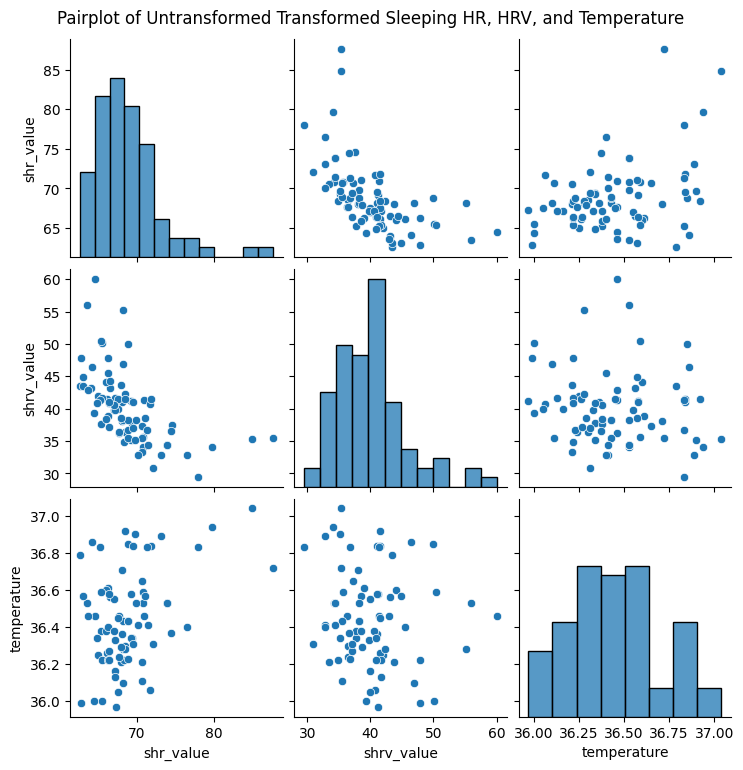

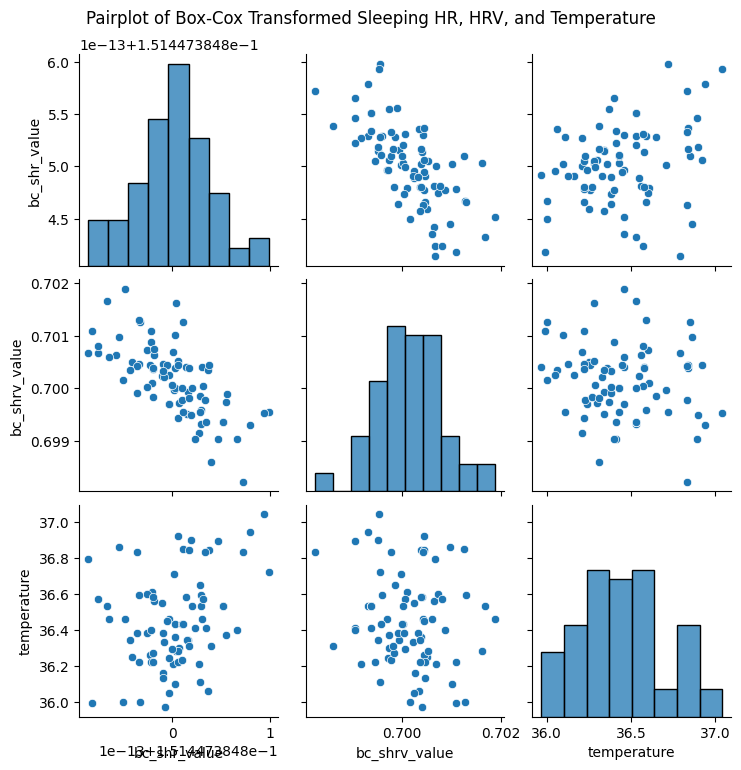

In [ ]:
from scipy.stats import boxcox
import seaborn as sns
import matplotlib.pyplot as plt

# MAN(C)OVA assumes normality, so transformation is needed
# Box-Cox Transformation (because values are strictly positive)
analysis_df['bc_shr_value'], _ = boxcox(analysis_df['shr_value'])
analysis_df['bc_shrv_value'], _ = boxcox(analysis_df['shrv_value'])

# Visualize untransformed and transformed data
plot = sns.pairplot(analysis_df[["shr_value", "shrv_value", "temperature"]])
plot.figure.suptitle('Pairplot of Untransformed Transformed Sleeping HR, HRV, and Temperature', y=1.02)
plt.show()

plot = sns.pairplot(analysis_df[["bc_shr_value", "bc_shrv_value", "temperature"]])
plot.figure.suptitle('Pairplot of Box-Cox Transformed Sleeping HR, HRV, and Temperature', y=1.02)
plt.show()


We'll also need to check for multicollinearity. Anything over .80 presents a concern.

Oops i need to do more tests

https://www.statisticssolutions.com/checking-the-additional-assumptions-of-a-manova/

In [ ]:

analysis_df[["bc_shr_value", "bc_shrv_value", "temperature"]].corr()

,bc_shr_value,bc_shrv_value,temperature
bc_shr_value,1.000000,-0.688225,0.294331
bc_shrv_value,-0.688225,1.000000,-0.159864
temperature,0.294331,-0.159864,1.000000


## 4.2. One-Way ANOVA For Each Variable

- Independent Variable (IV): Menstrual phase (categorical: Follicular vs. Luteal)
- Dependent Variables (DVs):
    - shr_value (average sleeping heart rate)
    - shrv_value (average sleeping HRV)
    - temperature (basal body temperature)

Hypothesis:
- Null (H₀): Menstrual phase has no effect on HR or HRV.
- Alternative (H₁): At least one of the DVs (HR or HRV) significantly differs across phases.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


# One-way ANOVA for HR
model_hr = ols("shr_value ~ phase", data=analysis_df).fit()
anova_hr = sm.stats.anova_lm(model_hr, typ=2)
print("One-Way ANOVA for Heart Rate:")
print(anova_hr)
print("\n")

# One-way ANOVA for HRV
model_hrv = ols("shrv_value ~ phase", data=analysis_df).fit()
anova_hrv = sm.stats.anova_lm(model_hrv, typ=2)
print("One-Way ANOVA for Heart Rate Variability:")
print(anova_hrv)
print("\n")

# One-way ANOVA for Temperature
model_temperature = ols("temperature ~ phase", data=analysis_df).fit()
anova_temperature = sm.stats.anova_lm(model_temperature, typ=2)
print("One-Way ANOVA for Basal Body Temperature:")
print(anova_temperature)
print("\n")

# One-way ANOVA for Sleep Duration
model_sleep_duration = ols("sleep_duration ~ phase", data=analysis_df).fit()
anova_sleep_duration = sm.stats.anova_lm(model_sleep_duration, typ=2)
print("One-Way ANOVA for Sleep Duration:")
print(anova_sleep_duration)
print("\n")

One-Way ANOVA for Heart Rate:
          sum_sq    df     F  PR(>F)
phase     216.72  1.00 13.15    0.00
Residual 1351.65 82.00   NaN     NaN


One-Way ANOVA for Heart Rate Variability:
          sum_sq    df    F  PR(>F)
phase      95.56  1.00 3.25    0.08
Residual 2409.53 82.00  NaN     NaN


One-Way ANOVA for Basal Body Temperature:
          sum_sq    df     F  PR(>F)
phase       2.31  1.00 60.02    0.00
Residual    3.15 82.00   NaN     NaN


One-Way ANOVA for Sleep Duration:
                     sum_sq    df    F  PR(>F)
phase     38066902889131.48  1.00 8.25    0.01
Residual 378262051196107.50 82.00  NaN     NaN




## 4.3. MANCOVA (finally!)

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# Run MANCOVA (Adding 'sleep_duration' as a covariate)
maov = MANOVA.from_formula('bc_shr_value + bc_shrv_value + temperature ~ phase + sleep_duration', data=analysis_df)
print(maov.mv_test())

                         Multivariate linear model
                                                                            
----------------------------------------------------------------------------
       Intercept            Value      Num DF  Den DF     F Value     Pr > F
----------------------------------------------------------------------------
          Wilks' lambda         0.0000 3.0000 79.0000 3560366430.3477 0.0000
         Pillai's trace         1.0000 3.0000 79.0000 3560366430.3477 0.0000
 Hotelling-Lawley trace 135203788.4942 3.0000 79.0000 3560366430.3477 0.0000
    Roy's greatest root 135203788.4942 3.0000 79.0000 3560366430.3477 0.0000
----------------------------------------------------------------------------
                                                                            
-------------------------------------------------------------------------------
             phase             Value     Num DF     Den DF    F Value    Pr > F
-------------------